In [20]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, explode, count, desc, avg

# Khởi tạo
spark = (SparkSession.builder
    .appName("TFT-Notebook")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)

# Đọc dữ liệu
print(">>> Đang đọc dữ liệu...")
df = spark.read.option("recursiveFileLookup", "true") \
               .option("inferSchema", "true") \
               .json("./data_3580_matches") # Đường dẫn tương đối từ vị trí file notebook

# Xử lý lớp bọc 'data' nếu có
if "data" in df.columns and "info" not in df.columns:
    df = df.select("data.*")

df.cache() # Lưu vào RAM
print(f"Done! Đã load {df.count()} trận đấu.")


>>> Đang đọc dữ liệu...


25/11/26 03:02:00 WARN CacheManager: Asked to cache already cached data.        


Done! Đã load 3580 trận đấu.


#  1. Phân Tích Chi Tiết Cấu Trúc Dữ Liệu (Detailed Schema Analysis)

Dữ liệu trận đấu TFT thu thập từ Riot API có cấu trúc **Nested JSON** (lồng nhau). Dựa trên kết quả `printSchema()` từ Apache Spark, dữ liệu được tổ chức thành các tầng thông tin như sau:

### 1.1. Cấu trúc Gốc (Root Structure)

Dữ liệu được chia thành 2 nhánh chính ở tầng ngoài cùng:

  * **`metadata`**: Chứa thông tin định danh kỹ thuật.
      * `data_version`: Phiên bản dữ liệu.
      * `match_id`: Mã trận đấu (VD: VN2\_...).
      * `participants`: Danh sách PUUID người chơi tham gia (dạng chuỗi).
  * **`info`**: Chứa toàn bộ dữ liệu diễn biến và kết quả trận đấu.

### 1.2. Thông tin Trận đấu (`info` Object)

Nhánh `info` chứa các thông số môi trường của ván đấu:

| Tên trường (Field) | Kiểu dữ liệu | Mô tả | Nguồn ảnh |
| :--- | :--- | :--- | :--- |
| **`gameId`** | `Long` | ID số của ván đấu. | |
| **`game_datetime`** | `Long` | Thời gian diễn ra (Unix Timestamp - ms). | |
| **`game_length`** | `Double` | Thời lượng ván đấu (giây). | |
| **`tft_game_type`** | `String` | Chế độ chơi (standard, hyperroll, v.v.). | |
| **`tft_set_number`** | `Long` | Mùa giải (Set) của TFT. | |
| **`queue_id`** | `Long` | ID hàng chờ (Queue ID) để phân loại Rank/Normal. | |

### 1.3. Chi tiết Người Chơi (`info.participants`)

Đây là phần quan trọng nhất, chứa mảng 8 người chơi (`participants`). Mỗi người chơi có các thông số sau:

**A. Kết quả & Chỉ số cơ bản:**

  * `puuid`: Mã định danh người chơi.
  * `riotIdGameName`: Tên hiển thị (Ingame Name).
  * **`placement`**: Thứ hạng (1-8). Chỉ số quan trọng nhất (Target Variable).
  * `level`: Cấp độ linh thú.
  * `gold_left`: Vàng còn dư.
  * `players_eliminated`: Số người chơi đã loại được.
  * `total_damage_to_players`: Tổng sát thương gây ra lên người chơi khác.
  * `time_eliminated`: Thời gian bị loại (giây).

**B. Đội hình Tướng (`units` Array):**
Mỗi tướng trên bàn cờ được mô tả bởi:

  * `character_id`: Tên tướng (VD: TFT15\_Jinx).
  * `tier`: Cấp sao của tướng (1, 2, 3 sao).
  * `rarity`: Độ hiếm (Giá tiền).
  * `itemNames`: Mảng chứa tên các trang bị tướng đang cầm.

**C. Tộc/Hệ Kích hoạt (`traits` Array):**
Các tộc hệ đang có trên bàn cờ:

  * `name`: Tên tộc/hệ.
  * `num_units`: Số lượng tướng thuộc hệ này.
  * `tier_current`: Mốc kích hoạt hiện tại (0: chưa kích, 1: Mốc 1...).
  * `style`: Kiểu hiển thị huy hiệu tộc hệ (Đồng, Bạc, Vàng, Kim Cương).

In [21]:
# In ra cấu trúc cây (Schema) của dữ liệu để đối chiếu
print("=== CẤU TRÚC DỮ LIỆU (SCHEMA) ===")
df.printSchema()

=== CẤU TRÚC DỮ LIỆU (SCHEMA) ===
root
 |-- info: struct (nullable = true)
 |    |-- endOfGameResult: string (nullable = true)
 |    |-- gameCreation: long (nullable = true)
 |    |-- gameId: long (nullable = true)
 |    |-- game_datetime: long (nullable = true)
 |    |-- game_length: double (nullable = true)
 |    |-- game_version: string (nullable = true)
 |    |-- mapId: long (nullable = true)
 |    |-- participants: array (nullable = true)
 |    |    |-- element: struct (containsNull = true)
 |    |    |    |-- companion: struct (nullable = true)
 |    |    |    |    |-- content_ID: string (nullable = true)
 |    |    |    |    |-- item_ID: long (nullable = true)
 |    |    |    |    |-- skin_ID: long (nullable = true)
 |    |    |    |    |-- species: string (nullable = true)
 |    |    |    |-- gold_left: long (nullable = true)
 |    |    |    |-- last_round: long (nullable = true)
 |    |    |    |-- level: long (nullable = true)
 |    |    |    |-- missions: struct (nullable = 

In [23]:
from pyspark.sql.functions import col, from_unixtime

# Chọn lọc các cột quan trọng để hiển thị
df.select(
    col("info.gameId"),
    col("info.tft_game_type"),
    from_unixtime(col("info.game_datetime") / 1000).alias("Ngay_Gio"), # Chuyển timestamp ms -> giây
    col("info.participants")[0].getField("riotIdGameName").alias("Ten_Nguoi_Choi_1"),
    col("info.participants")[0].getField("placement").alias("Top_Nguoi_Choi_1")
).show(5, truncate=False)

+----------+-------------+-------------------+----------------+----------------+
|gameId    |tft_game_type|Ngay_Gio           |Ten_Nguoi_Choi_1|Top_Nguoi_Choi_1|
+----------+-------------+-------------------+----------------+----------------+
|1096499747|pairs        |2025-10-17 19:54:12|iumyngoc1       |8               |
|1096456564|pairs        |2025-10-17 18:45:11|Winx HợpRose    |4               |
|1096349715|standard     |2025-10-17 17:14:23|chipchip304     |7               |
|1084143459|standard     |2025-10-09 19:30:50|Minh Quoc       |4               |
|1083984919|standard     |2025-10-09 17:08:19|Ai Phuoc        |4               |
+----------+-------------+-------------------+----------------+----------------+
only showing top 5 rows



#  Phân Tích Thời Lượng Trận Đấu (Game Length Analysis)

Đoạn code này thực hiện truy vấn đơn giản nhưng quan trọng để kiểm tra chất lượng dữ liệu và tìm ra các ván đấu "kỳ lạ" (Outliers).

### Mục đích:

1.  **Kiểm tra dữ liệu:** Đảm bảo trường `game_length` được đọc đúng (không bị null hoặc số âm).
2.  **Phát hiện bất thường:** Các trận đấu quá dài (\> 40 phút) thường là dấu hiệu của những ván đấu căng thẳng hoặc chế độ chơi đặc biệt (PVE, Hyper Roll...).

### Giải thích logic code:

  * **`select(...)`**: Chỉ chọn ra 3 cột cần thiết để hiển thị:
      * `info.gameId`: Để định danh trận đấu.
      * `info.tft_game_type`: Để biết đó là Rank, Normal hay chế độ khác.
      * `info.game_length`: Thời lượng (giây).
  * **`.alias(...)`**: Đổi tên cột tiếng Anh sang tiếng Việt cho dễ đọc (`Thoi_luong_giay`).
  * **`.orderBy(desc("Thoi_luong_giay"))`**: Sắp xếp giảm dần để đưa các trận dài nhất lên đầu.
  * **`.show(5)`**: Chỉ in ra 5 dòng đầu tiên.


In [24]:
from pyspark.sql.functions import col, desc, explode, count

# Giả sử df là DataFrame bạn đã load xong
print("=== TOP 5 TRẬN ĐẤU DÀI NHẤT ===")
df.select(
    col("info.gameId").alias("Game_ID"),
    col("info.tft_game_type").alias("Che_Do"),
    col("info.game_length").alias("Thoi_luong_giay")
).orderBy(desc("Thoi_luong_giay")).show(5)

=== TOP 5 TRẬN ĐẤU DÀI NHẤT ===
+----------+--------+-----------------+
|   Game_ID|  Che_Do|  Thoi_luong_giay|
+----------+--------+-----------------+
|1095766413|standard|  2717.2607421875|
|1095766413|standard|  2717.2607421875|
|1096113945|standard|   2636.548828125|
|1085532476|standard|2576.858642578125|
|1096473179|     pve| 2569.35791015625|
+----------+--------+-----------------+
only showing top 5 rows



#  Top Tướng Phổ Biến Nhất (Most Played Champions)

Đoạn code này sẽ trả lời câu hỏi: **"Vị tướng nào đang xuất hiện nhiều nhất trong các trận đấu?"** (Pick Rate).

**Giải thích logic xử lý:**
Dữ liệu tướng (`units`) nằm lồng rất sâu trong cấu trúc JSON: `Match` -> `Participants` (mảng) -> `Units` (mảng). Do đó, chúng ta cần thực hiện quy trình "gỡ rối" (Unnesting) qua 2 bước:

1.  **Bung mảng Người chơi (`participants`)**: Dùng hàm `explode` để tách 1 trận đấu thành 8 dòng dữ liệu tương ứng với 8 người chơi.
2.  **Bung mảng Tướng (`units`)**: Tiếp tục dùng `explode` để tách mỗi người chơi thành nhiều dòng tương ứng với số tướng họ có trên bàn cờ.
3.  **Tổng hợp (`Aggregation`)**: Cuối cùng, nhóm theo tên tướng (`character_id`) và đếm số lần xuất hiện để tìm ra Top 5.

In [25]:
print("=== TOP 5 TƯỚNG ĐƯỢC CHƠI NHIỀU NHẤT ===")

# Bước 1: Bung mảng participants (người chơi)
df_players = df.select(explode(col("info.participants")).alias("player"))

# Bước 2: Bung mảng units (tướng) từ người chơi
df_units = df_players.select(explode(col("player.units")).alias("unit"))

# Bước 3: Đếm và sắp xếp
df_units.groupBy("unit.character_id") \
    .count() \
    .orderBy(desc("count")) \
    .withColumnRenamed("count", "So_lan_xuat_hien") \
    .show(5, truncate=False)

=== TOP 5 TƯỚNG ĐƯỢC CHƠI NHIỀU NHẤT ===
+--------------+----------------+
|character_id  |So_lan_xuat_hien|
+--------------+----------------+
|TFT15_KSante  |10325           |
|TFT15_JarvanIV|9267            |
|TFT15_Ryze    |9168            |
|TFT15_Janna   |8583            |
|TFT15_Aatrox  |8278            |
+--------------+----------------+
only showing top 5 rows




# Top Tộc/Hệ Được Kích Hoạt Nhiều Nhất (Most Active Traits)

Đoạn code này sẽ thống kê: **"Người chơi thường kích hoạt Tộc/Hệ nào nhất trong đội hình của mình?"**.

**Lưu ý quan trọng:**
Trong dữ liệu, trường `traits` chứa danh sách **tất cả** các tộc hệ của các tướng trên bàn cờ, kể cả những hệ **chưa đủ mốc kích hoạt** (Ví dụ: Có 1 tướng Pháo Thủ nhưng cần 2 tướng mới kích hoạt hiệu ứng).
Do đó, chúng ta cần lọc (`filter`) chỉ lấy những Tộc/Hệ có `tier_current > 0` (đã kích hoạt ít nhất mốc 1).

**Các bước xử lý:**
1.  **Bung mảng Người chơi**: Tương tự như trên, tách thành 8 dòng/trận.
2.  **Bung mảng Tộc/Hệ (`traits`)**: Tách danh sách tộc hệ của mỗi người chơi ra từng dòng.
3.  **Lọc (Filter)**: Chỉ giữ lại các dòng có `trait.tier_current > 0`.
4.  **Tổng hợp**: Đếm số lần xuất hiện của từng Tộc/Hệ và sắp xếp giảm dần.


In [4]:
print("=== TOP 5 TỘC/HỆ (TRAITS) HOT NHẤT ===")

# Bước 1: Bung mảng participants
df_players = df.select(explode(col("info.participants")).alias("player"))

# Bước 2: Bung mảng traits
df_traits = df_players.select(explode(col("player.traits")).alias("trait"))

# Bước 3: Đếm (Lọc những trait có tier_current > 0, tức là có kích hoạt)
df_traits.filter(col("trait.tier_current") > 0) \
    .groupBy("trait.name") \
    .count() \
    .orderBy(desc("count")) \
    .withColumnRenamed("count", "So_lan_kich_hoat") \
    .show(5, truncate=False)

=== TOP 5 TỘC/HỆ (TRAITS) HOT NHẤT ===


+-----------------+----------------+
|name             |So_lan_kich_hoat|
+-----------------+----------------+
|TFT15_OldMentor  |19254           |
|TFT15_Protector  |11883           |
|TFT15_Bastion    |11368           |
|TFT15_Strategist |10237           |
|TFT15_Heavyweight|9751            |
+-----------------+----------------+
only showing top 5 rows



# Top 10 Tướng

Đoạn code này thực hiện việc trích xuất và đếm tần suất xuất hiện của từng vị tướng trong tập dữ liệu trận đấu. Cụ thể các bước như sau:

1.  **Bung nén dữ liệu (Unnesting):**

      * Dữ liệu ban đầu ở dạng lồng nhau: `Match` (trận đấu) -\> `Participants` (8 người chơi) -\> `Units` (nhiều tướng).
      * **`explode(col("info.participants"))`**: Bước này "đập vỡ" một dòng dữ liệu trận đấu thành 8 dòng dữ liệu riêng biệt, mỗi dòng tương ứng với một người chơi trong trận đấu đó. Kết quả được gán bí danh là `player`.
      * **`explode(col("player.units"))`**: Tiếp tục "đập vỡ" mỗi dòng dữ liệu người chơi thành nhiều dòng, mỗi dòng tương ứng với một vị tướng mà người chơi đó sử dụng. Kết quả được gán bí danh là `unit`.
      * Kết quả sau bước 1 là một DataFrame phẳng (`df_units_raw`), trong đó mỗi dòng đại diện cho một vị tướng xuất hiện trên bàn cờ.

2.  **Tính toán và Sắp xếp (Aggregation & Sorting):**

      * **`.groupBy("unit.character_id")`**: Nhóm các dòng dữ liệu lại theo tên định danh của tướng (ví dụ: `TFT15_Leesin`, `TFT15_Jinx`).
      * **`.count()`**: Đếm số lượng dòng trong mỗi nhóm. Đây chính là tổng số lần vị tướng đó xuất hiện trong toàn bộ dữ liệu.
      * **`.orderBy(desc("count"))`**: Sắp xếp danh sách kết quả theo thứ tự giảm dần của số lần xuất hiện (từ nhiều nhất đến ít nhất).
      * **`.withColumnRenamed(...)`**: Đổi tên cột kết quả từ mặc định `count` sang `So_lan_xuat_hien` cho dễ hiểu.
      * **`.limit(10)`**: Chỉ lấy 10 vị tướng đứng đầu danh sách. Đây là bước quan trọng giúp tối ưu hiệu năng, vì chúng ta chỉ quan tâm đến những tướng phổ biến nhất (Meta), không cần xử lý toàn bộ danh sách hàng trăm tướng.

3.  **Hiển thị kết quả:**

      * `df_top_units.show()`: In ra bảng kết quả Top 10 tướng cùng số lần xuất hiện tương ứng.

In [9]:
from pyspark.sql.functions import col, desc, explode

# 1. Bung nén dữ liệu (nếu chưa có df_units)
df_players = df.select(explode(col("info.participants")).alias("player"))
df_units_raw = df_players.select(explode(col("player.units")).alias("unit"))

# 2. Tính toán Top 10 và LƯU VÀO BIẾN (thay vì chỉ .show())
df_top_units = df_units_raw.groupBy("unit.character_id") \
    .count() \
    .orderBy(desc("count")) \
    .withColumnRenamed("count", "So_lan_xuat_hien") \
    .limit(10) # Chỉ lấy 10 dòng đầu ngay từ Spark cho nhẹ

print("Đã tính toán xong Top 10 tướng!")
df_top_units.show() # In ra kiểm tra

Đã tính toán xong Top 10 tướng!
+--------------+----------------+
|  character_id|So_lan_xuat_hien|
+--------------+----------------+
|  TFT15_KSante|           10325|
|TFT15_JarvanIV|            9267|
|    TFT15_Ryze|            9168|
|   TFT15_Janna|            8583|
|  TFT15_Aatrox|            8278|
|   TFT15_Swain|            8061|
|   TFT15_Braum|            7892|
|  TFT15_Kobuko|            7198|
|    TFT15_Udyr|            6952|
|    TFT15_Zyra|            6596|
+--------------+----------------+



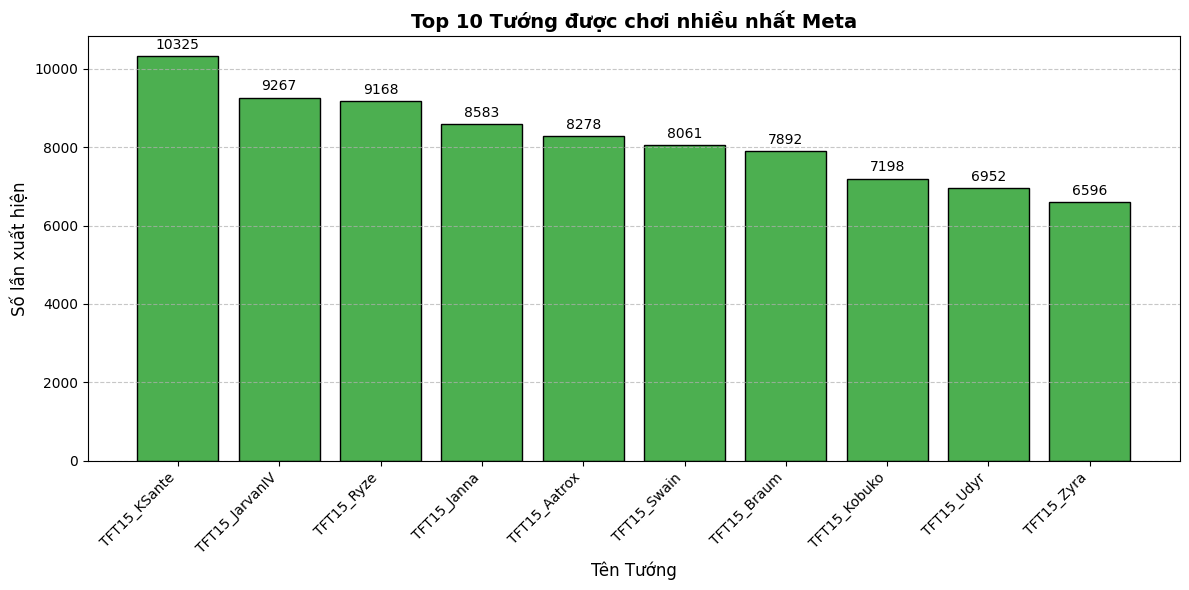

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Chuyển kết quả Top 10 sang Pandas
pdf_units = df_top_units.toPandas()

# 2. Vẽ biểu đồ
plt.figure(figsize=(12, 6))
bars = plt.bar(pdf_units['character_id'], pdf_units['So_lan_xuat_hien'], color='#4CAF50', edgecolor='black')

# Trang trí
plt.xlabel('Tên Tướng', fontsize=12)
plt.ylabel('Số lần xuất hiện', fontsize=12)
plt.title('Top 10 Tướng được chơi nhiều nhất Meta', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Hiện số trên cột
plt.bar_label(bars, fmt='%d', padding=3)

plt.tight_layout() # Tự động căn chỉnh lề cho khỏi bị cắt chữ
plt.show()

#  Phân Tích Meta Tướng & Tối Ưu Trang Bị (Advanced Champion Analysis)

Đoạn code này thực hiện một bước phân tích nâng cao hơn so với việc chỉ đếm số lần xuất hiện. Chúng ta sẽ đánh giá sức mạnh thực sự của các vị tướng dựa trên **Thứ hạng trung bình (Average Placement)** và tìm ra **Lối lên đồ (Item Build)** hiệu quả nhất.

**1. Chuẩn bị dữ liệu (Data Preparation):**
* Trước tiên, chúng ta cần bung nén dữ liệu để có được thông tin của từng người chơi trong mỗi ván đấu (`df_players`).
* **Quan trọng:** Cần giữ lại cột `placement` (thứ hạng 1-8) của người chơi. Đây là chỉ số quan trọng nhất để đánh giá xem một vị tướng hay đội hình có giúp người chơi chiến thắng hay không.

**2. Đánh giá Meta Tướng (Champion Meta):**
* Chúng ta nhóm dữ liệu theo từng tướng (`character_id`) và tính toán 2 chỉ số:
    * **`So_tran_choi` (Pick Rate):** Số lần tướng được sử dụng.
    * **`Thu_hang_TB` (Avg Placement):** Thứ hạng trung bình của người chơi khi sử dụng tướng này.
* **Tiêu chí đánh giá:** Một tướng được coi là **"Meta" (Mạnh)** khi có số trận chơi cao và thứ hạng trung bình thấp (càng gần 1.0 càng tốt).
    * *Avg Place < 4.0:* Rất mạnh (Thường xuyên vào Top 4).
    * *Avg Place > 4.5:* Yếu hoặc chỉ dùng để giữ máu đầu game.

**3. Tối ưu hóa trang bị (Itemization):**
* Phần cuối của code giúp trả lời câu hỏi: *"Nên lắp đồ gì cho tướng X?"*.
* Bằng cách lọc ra tất cả các lần xuất hiện của một tướng cụ thể (ví dụ: `TFT15_Leesin`) và thống kê các trang bị họ mang, ta sẽ tìm ra bộ trang bị "trấn phái" (Best-in-slot) được cộng đồng tin dùng nhất.


# Gợi ý:
* Bạn có thể thay đổi biến `target_champ` thành tên bất kỳ vị tướng nào khác (ví dụ: `TFT15_Jinx`, `TFT15_Vi`) để xem xu hướng lên đồ của tướng đó.
* Kết quả `Thu_hang_TB` là thước đo khách quan nhất để bạn quyết định có nên "spam" vị tướng đó trong rank hay không.

In [13]:
from pyspark.sql.functions import col, explode, avg, count, desc, first

# --- BƯỚC 1: Chuẩn bị dữ liệu (Bung nén người chơi ra) ---
# Quan trọng: Phải giữ lại cột 'placement' (thứ hạng) để tính độ mạnh yếu
df_players = df.select(
    col("info.gameId"),
    col("info.game_datetime"),
    explode(col("info.participants")).alias("player")
).select(
    col("player.puuid"),
    col("player.placement"), # Top 1, Top 8...
    col("player.units"),
    col("player.traits")
)

# --- BƯỚC 2: Phân tích Tướng (Top Meta) ---
# Bung nén units
df_units = df_players.select("placement", explode("units").alias("unit"))

# Tính toán: Số lần chơi + Thứ hạng trung bình
df_champ_stats = df_units.groupBy("unit.character_id") \
    .agg(
        count("*").alias("So_tran_choi"),
        avg("placement").alias("Thu_hang_TB")
    ) \
    .filter(col("So_tran_choi") > 100) \
    .orderBy(col("Thu_hang_TB").asc()) # Top 1 là số nhỏ nhất -> xếp tăng dần

print("=== TOP 10 TƯỚNG CÓ TỈ LỆ THẮNG CAO NHẤT (META) ===")
df_champ_stats.show(10)

# --- BƯỚC 3: Tìm đồ tốt nhất cho 1 con tướng (Ví dụ: Jinx) ---
target_champ = "tft15_leesin" # Bạn thay tên tướng muốn tìm vào đây

df_items = df_units.filter(col("unit.character_id") == target_champ) \
    .select(explode("unit.itemNames").alias("item_name"))

print(f"=== TOP 5 TRANG BỊ CHO {target_champ} ===")
df_items.groupBy("item_name") \
    .count() \
    .orderBy(desc("count")) \
    .show(5, truncate=False)

=== TOP 10 TƯỚNG CÓ TỈ LỆ THẮNG CAO NHẤT (META) ===
+-----------------+------------+------------------+
|     character_id|So_tran_choi|       Thu_hang_TB|
+-----------------+------------+------------------+
|     tft15_leesin|        5071| 3.594557286531256|
|      TFT15_Braum|        7892|  3.73682209832742|
|  TFT15_Seraphine|        4012|3.8457128614157527|
|TFT15_TwistedFate|        3994|3.8627941912869304|
|       TFT15_Zyra|        6596|3.9011522134627046|
|      TFT15_Varus|        2735|3.9904936014625227|
|       TFT15_Ekko|         147|4.0272108843537415|
|      TFT15_Ziggs|        2142| 4.034547152194211|
|       TFT15_Yone|        1756|4.0842824601366745|
|       TFT15_Gwen|        2799| 4.124687388352983|
+-----------------+------------+------------------+
only showing top 10 rows

=== TOP 5 TRANG BỊ CHO tft15_leesin ===
+---------------------------+-----+
|item_name                  |count|
+---------------------------+-----+
|TFT_Item_SteraksGage       |1221 |
|TFT_Item_

# Đánh Giá Hiệu Quả Đội Hình (Synergy Performance)

Đoạn code này đi sâu hơn vào việc phân tích chiến thuật bằng cách trả lời câu hỏi: **"Kích hoạt Tộc/Hệ nào ở mốc bao nhiêu tướng thì đạt tỉ lệ thắng cao nhất?"**.

**Điểm đặc biệt trong logic xử lý:**

1.  **Lọc Tộc/Hệ Kích Hoạt (`Filter Active Traits`):**
    * Dữ liệu thô chứa mọi tộc hệ của tướng (VD: Jinx có hệ *Phao Thủ*, nhưng nếu chỉ có 1 mình Jinx thì hệ này chưa kích hoạt).
    * Điều kiện `trait.tier_current > 0` giúp loại bỏ nhiễu, chỉ giữ lại những Tộc/Hệ thực sự phát huy tác dụng trong trận đấu.

2.  **Phân Loại Theo Mốc (`Group By Num Units`):**
    * Chúng ta nhóm theo cả `trait.name` (Tên) và `trait.num_units` (Số lượng tướng).
    * **Lý do:** Sức mạnh của *3 Ionia* hoàn toàn khác với *6 Ionia* hay *9 Ionia*. Việc tách biệt này giúp xác định chính xác "mốc sức mạnh" (Power Spike) của từng đội hình.

3.  **Chỉ Số Đánh Giá:**
    * **`So_tran_choi`**: Độ phổ biến của bài đấu.
    * **`Thu_hang_TB` (Avg Placement)**: Thước đo sức mạnh thực sự. Giá trị càng gần **1.0** chứng tỏ đội hình này thường xuyên lọt Top 1.

# Cách đọc kết quả:
* Nếu thấy một Tộc/Hệ có **Số trận chơi ít** nhưng **Thứ hạng TB rất thấp** (VD: 1.5 - 2.0) $\rightarrow$ Đây có thể là bài "Exodia" (bài rác/bài độc lạ) cực mạnh nhưng khó xây dựng (cần nhiều Ấn/Xẻng).
* Nếu thấy Tộc/Hệ có **Số trận chơi cao** và **Thứ hạng TB ổn định** (VD: 3.5 - 4.0) $\rightarrow$ Đây là bài Meta an toàn để leo rank (Spam comp).

In [14]:
from pyspark.sql.functions import col, explode, avg, count, desc

# --- BƯỚC 1: Dùng lại df_players ở trên ---
# Bung nén traits (Tộc hệ)
df_traits_raw = df_players.select("placement", explode("traits").alias("trait"))

# --- BƯỚC 2: Thống kê Meta Tộc Hệ ---
# Chỉ lấy những trait ĐƯỢC KÍCH HOẠT (tier_current > 0)
# Ví dụ: Có 1 con Bastion nhưng mốc kích hoạt là 2 -> tier_current = 0 -> Không tính
df_trait_stats = df_traits_raw.filter(col("trait.tier_current") > 0) \
    .groupBy("trait.name", "trait.num_units") \
    .agg(
        count("*").alias("So_tran_choi"),
        avg("placement").alias("Thu_hang_TB")
    ) \
    .filter(col("So_tran_choi") > 50) \
    .orderBy(col("Thu_hang_TB").asc()) # Xếp theo thứ hạng tốt nhất

print("=== TOP 10 ĐỘI HÌNH TỘC/HỆ MẠNH NHẤT (AVG PLACEMENT) ===")
df_trait_stats.show(10, truncate=False)

=== TOP 10 ĐỘI HÌNH TỘC/HỆ MẠNH NHẤT (AVG PLACEMENT) ===


+------------------+---------+------------+------------------+
|name              |num_units|So_tran_choi|Thu_hang_TB       |
+------------------+---------+------------+------------------+
|TFT15_Strategist  |5        |424         |2.599056603773585 |
|TFT15_Duelist     |4        |226         |3.2389380530973453|
|TFT15_Prodigy     |3        |860         |3.4930232558139536|
|TFT15_Strategist  |4        |1621        |3.5058605798889575|
|TFT15_StarGuardian|9        |77          |3.5844155844155843|
|TFT15_Destroyer   |5        |251         |3.605577689243028 |
|TFT15_DragonFist  |1        |4822        |3.660929075072584 |
|TFT15_Edgelord    |4        |245         |3.6612244897959183|
|TFT15_ElTigre     |1        |7667        |3.758706143211165 |
|TFT15_Sniper      |5        |61          |3.7704918032786887|
+------------------+---------+------------+------------------+
only showing top 10 rows

